# 🔮 AirLyst: [05] Advanced 72-Hour Forecasting Pipeline
**Mission: Predict Air Quality Trends for Islamabad using Integrated Air & Weather Data**

In this notebook, we combine future weather predictions (wind, pressure, temp) with future pollutant trends (PM2.5, PM10) to generate a highly accurate 72-hour AQI forecast.

---

In [13]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import requests
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# 1. Setup Environment & Paths
try:
    ROOT_DIR = Path.cwd().parent.parent
    if not (ROOT_DIR / "backend").exists():
        ROOT_DIR = Path("C:/Users/Dell/Desktop/AirLyst")
except:
    ROOT_DIR = Path("C:/Users/Dell/Desktop/AirLyst")

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from backend.config.settings import settings

print("🚀 AirLyst Forecasting Engine Ready.")
print(f"📍 Project Root: {ROOT_DIR}")

🚀 AirLyst Forecasting Engine Ready.
📍 Project Root: c:\Users\Dell\Desktop\AirLyst


## 💾 1. Load Trained Model
We load our Random Forest model which has been trained on historical Islamabad data.

In [14]:
model_path = ROOT_DIR / "backend/models/aqi_model.joblib"
if not model_path.exists():
    raise FileNotFoundError(f"❌ ERROR: Model not found at {model_path}. Please train the model first!")

model = joblib.load(model_path)
feature_cols = list(model.feature_names_in_)
print("✅ Model loaded successfully.")
print(f"Input Features required ({len(feature_cols)}): \n{feature_cols}")

✅ Model loaded successfully.
Input Features required (23): 
['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'temperature_2m', 'surface_pressure', 'wind_speed_10m', 'hour', 'day', 'month', 'day_of_week', 'is_weekend', 'pm2_5_lag_1h', 'pm2_5_lag_3h', 'pm2_5_lag_6h', 'pm2_5_lag_24h', 'us_aqi_lag_1h', 'us_aqi_lag_3h', 'us_aqi_lag_6h', 'us_aqi_lag_24h', 'pm2_5_rolling_6h', 'pm2_5_rolling_24h']


## 📡 2. Integrated Data Acquisition
We fetch forecasts from two endpoints:
1. **Air Quality API**: Future pollutant levels (PM2.5, PM10, etc.)
2. **Weather API**: Future atmospheric conditions (Wind, Pressure, Temp)

In [15]:
print("📡 Fetching integrated forecasts...")

# Air Forecast Params
air_params = {
    "latitude": settings.LATITUDE, "longitude": settings.LONGITUDE,
    "hourly": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,us_aqi",
    "forecast_days": 3
}

# Weather Forecast Params
weather_params = {
    "latitude": settings.LATITUDE, "longitude": settings.LONGITUDE,
    "hourly": "temperature_2m,surface_pressure,wind_speed_10m",
    "forecast_days": 3, "timezone": "auto"
}

try:
    # Fetch both
    air_res = requests.get(settings.AIR_URL, params=air_params, timeout=15).json()
    weather_res = requests.get(settings.FORECAST_URL, params=weather_params, timeout=15).json()
    
    df_air = pd.DataFrame(air_res["hourly"])
    df_weather = pd.DataFrame(weather_res["hourly"])
    
    # Merge on 'time'
    df_future = pd.merge(df_air, df_weather, on='time')
    df_future['time'] = pd.to_datetime(df_future['time'])
    
    # Rename API AQI for clarity
    df_future = df_future.rename(columns={'us_aqi': 'fetched_api_aqi'})
    
    print(f"✅ Successfully integrated {len(df_future)} hours of future features.")
except Exception as e:
    print(f"❌ API Fetch Failed: {e}. Check your internet connection.")

📡 Fetching integrated forecasts...
✅ Successfully integrated 72 hours of future features.


## 🧠 3. Feature Preparation
We calculate temporal features and bridge the gap between historical data and future predictions.

In [16]:
def get_aqi_status(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 150: return "Unhealthy (SG)"
    elif aqi <= 200: return "Unhealthy"
    elif aqi <= 300: return "Very Unhealthy"
    else: return "Hazardous"

def prepare_pipeline_features(df):
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df['hour'] = df['time'].dt.hour
    df['day'] = df['time'].dt.day
    df['month'] = df['time'].dt.month
    df['day_of_week'] = df['time'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # Ensure time sorted and unique
    df = df.sort_values('time').drop_duplicates(subset=['time'])
    
    # We need a 'us_aqi' column for lags, so we use the API value if target is missing
    if 'us_aqi' not in df.columns and 'fetched_api_aqi' in df.columns:
        df['us_aqi'] = df['fetched_api_aqi']
    
    # Lags for PM2.5
    for lag in [1, 3, 6, 24]:
        df[f'pm2_5_lag_{lag}h'] = df['pm2_5'].shift(lag)
    
    # Lags for US AQI
    for lag in [1, 3, 6, 24]:
        df[f'us_aqi_lag_{lag}h'] = df['us_aqi'].shift(lag)
    
    # Rolling windows for PM2.5
    df['pm2_5_rolling_6h'] = df['pm2_5'].rolling(window=6).mean()
    df['pm2_5_rolling_24h'] = df['pm2_5'].rolling(window=24).mean()
    
    return df

# Prepend history for lags
hist_path = ROOT_DIR / "backend/data/engineered_features.csv"
if hist_path.exists():
    df_hist = pd.read_csv(hist_path).tail(48)
    df_hist['time'] = pd.to_datetime(df_hist['time'])
    df_combined = pd.concat([df_hist, df_future], ignore_index=True)
    df_combined = prepare_pipeline_features(df_combined)
    df_ready = df_combined[df_combined['time'] > df_hist['time'].max()].copy()
else:
    df_ready = prepare_pipeline_features(df_future).fillna(0)

print("✅ Feature vectors prepared.")

✅ Feature vectors prepared.


## 🤖 4. Model Inference
Generating US AQI predictions for the next 72 hours.

In [21]:
X_future = df_ready[feature_cols]
df_ready['predicted_aqi'] = model.predict(X_future).round().astype(int)
df_ready['aqi_status'] = df_ready['predicted_aqi'].apply(get_aqi_status)

print("✅ 72-Hour Prediction Cycle Complete.")
print("Comparison: Fetched API AQI vs. Our ML Model Prediction")
display(df_ready[['time', 'fetched_api_aqi', 'predicted_aqi', 'aqi_status']].head(10))

✅ 72-Hour Prediction Cycle Complete.
Comparison: Fetched API AQI vs. Our ML Model Prediction


,time,fetched_api_aqi,predicted_aqi,aqi_status
72,2026-05-16 00:00:00,95.0,95,Moderate
73,2026-05-16 01:00:00,95.0,96,Moderate
74,2026-05-16 02:00:00,94.0,93,Moderate
75,2026-05-16 03:00:00,94.0,94,Moderate
76,2026-05-16 04:00:00,94.0,93,Moderate
77,2026-05-16 05:00:00,94.0,92,Moderate
78,2026-05-16 06:00:00,94.0,92,Moderate
79,2026-05-16 07:00:00,93.0,100,Moderate
80,2026-05-16 08:00:00,93.0,100,Moderate
81,2026-05-16 09:00:00,92.0,99,Moderate


## 📊 5. Visual Analytics
Comparing our Model's prediction with the API's baseline prediction.

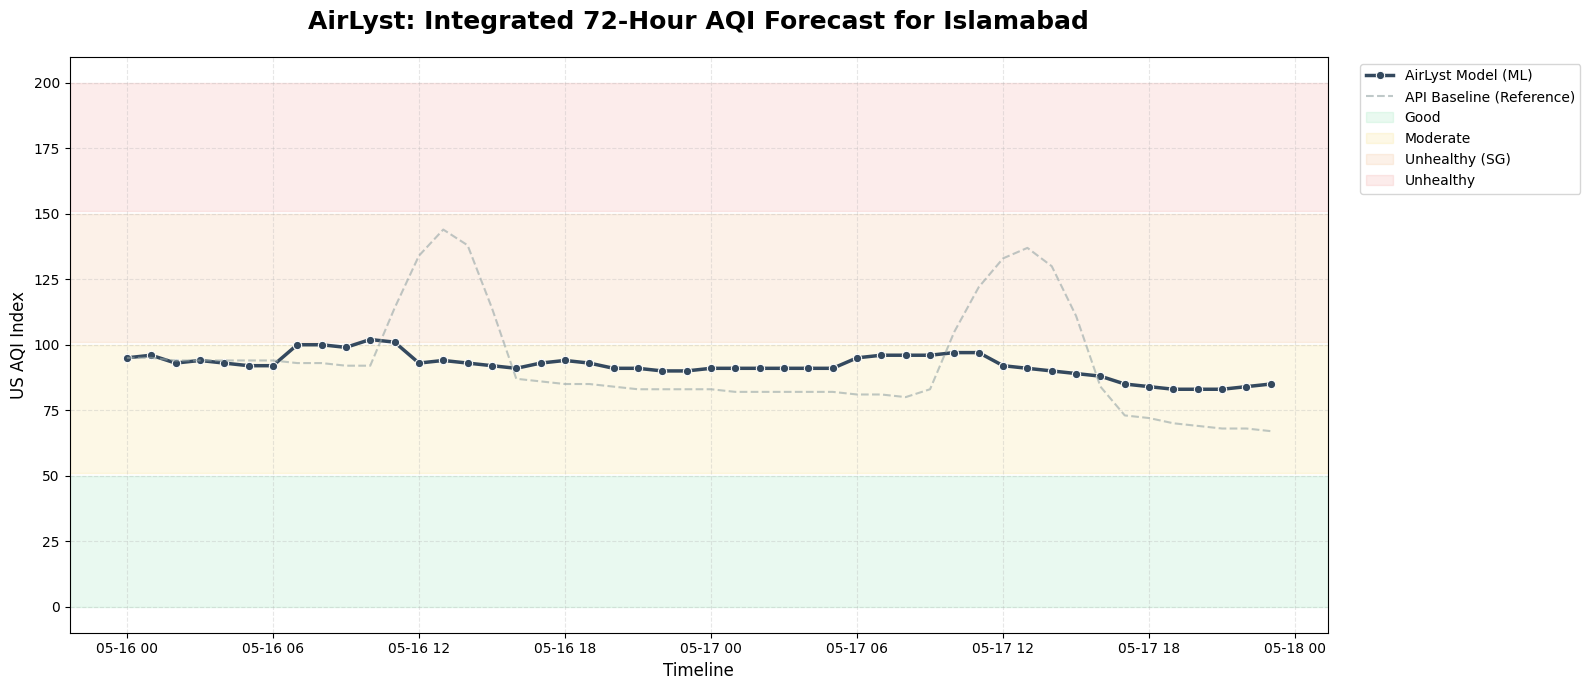

In [22]:
plt.style.use('seaborn-v0_8-muted')
plt.figure(figsize=(16, 7))

# Plot Trend
sns.lineplot(data=df_ready, x='time', y='predicted_aqi', marker='o', label='AirLyst Model (ML)', color='#34495e', linewidth=2.5)
sns.lineplot(data=df_ready, x='time', y='fetched_api_aqi', label='API Baseline (Reference)', color='#95a5a6', alpha=0.6, linestyle='--')

# AQI Zones
plt.axhspan(0, 50, color='#2ecc71', alpha=0.1, label='Good')
plt.axhspan(51, 100, color='#f1c40f', alpha=0.1, label='Moderate')
plt.axhspan(101, 150, color='#e67e22', alpha=0.1, label='Unhealthy (SG)')
plt.axhspan(151, 200, color='#e74c3c', alpha=0.1, label='Unhealthy')

plt.title(f"AirLyst: Integrated 72-Hour AQI Forecast for {settings.CITY}", fontsize=18, fontweight='bold', pad=20)
plt.ylabel("US AQI Index", fontsize=12)
plt.xlabel("Timeline", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 📅 6. Executive Summary

In [23]:
df_ready['date'] = df_ready['time'].dt.date
summary = df_ready.groupby('date')['predicted_aqi'].mean().round().astype(int).reset_index()
summary['status'] = summary['predicted_aqi'].apply(get_aqi_status)

print(f"---  Islamabad 3-Day AQI Forecast ---")
for i, row in summary.iterrows():
    day_label = "TODAY" if i == 0 else f"DAY {i}"
    print(f"{day_label} ({row['date']}): {row['predicted_aqi']} AQI -> [{row['status']}]")

---  Islamabad 3-Day AQI Forecast ---
TODAY (2026-05-16): 94 AQI -> [Moderate]
DAY 1 (2026-05-17): 90 AQI -> [Moderate]
